# ДЗ #1: "Метрики и факторизаци"

Правила заполнения ноутбуков на авто-проверку:
- Повторить окружение преподавателя
    Python 3.13.0
    ```bash
    pip install implicit==0.7.2 requests==2.32.5 "rectools[lightfm]==0.17.0" pandas==2.3.3 numpy==2.4.1 scipy==1.17.0
- Пользователям Windows настоятельно рекомендуется использовать WSL для установки требуемых версий пакетов.
- Не добавлять новые импорты и не использовать дополнительные библиотеки. В противном случае ноутбук не пройдёт проверку и получит `0` баллов
- Писать код только в ячейках с пометкой # YOUR CODE HERE, сразу после этой пометки
- Не менять код преподавателя
- Не добавлять новые ячейки
- Следить, чтобы не было warning - они автоматом фейлят задание
- Перед сдачей проверить, что весь ноутбук прогонятся от начала до конца и все тесты проходят
- Код должен выполняться за разумное время — лимит 10 минут на 4 CPU и 16 GB RAM без использования GPU.

**В данном проекте вам нужно будет подбирать гипер-параметры моделей. Писать код для подбора гипер-параметров, использовать optuna и т.п. рекомендуем в отдельном ноутбуке.**

**Библиотеки implicit и lightfm не фиксируют random state при num_threads > 1. Если результат работы модели не сильно превышает необходимомый порог и рандом может опустить его ниже требуемого уровня, рекомендуем продолжить повышение качества модели: тюнинг гипер-параметров, подбор фичей, подбор метода обработки датасета**

**Важно: в заданиях есть скрытые тесты.**

In [1]:
!python -V

Python 3.13.15


In [2]:
# Make sure you don't add new imports to the notebook. The solution should be limited to these libraries.

import warnings
warnings.simplefilter("ignore")

import pandas as pd
import numpy as np
import time
import implicit
import rectools
import scipy
import requests

print(implicit.__version__)
print(rectools.__version__)
print(pd.__version__)
print(np.__version__)
print(scipy.__version__)
print(requests.__version__)

0.7.2
0.17.0
2.3.3
2.4.1
1.17.0
2.32.5


In [3]:
import os.path

from implicit.als import AlternatingLeastSquares
from lightfm import LightFM

from rectools import Columns
from rectools.metrics import MAP, MeanInvUserFreq
from rectools.dataset import Dataset
from rectools.models import ImplicitALSWrapperModel, LightFMWrapperModel, model_from_config

# For implicit ALS
import os
import threadpoolctl
os.environ["OPENBLAS_NUM_THREADS"] = "1"
threadpoolctl.threadpool_limits(1, "blas")

# Метрики

## Кейс 1. Олд-скульный тест на математику (8 баллов)

Перед тобой топ 5 рекомендаций от обученного алгоритма для 3-х тестовых юзеров в раскраске позитивам / негативам. У каждого тестового юзера было ровно 2 ground truth интеракции в тестовом периоде. Оранжевые кружки - это айтемы, с которыми юзер взаимодействовал в тестовом периоде, белые - с которыми не взаимодействовал.

Твоя задача - посчитать метрики для оценки качества алгоритма. Сторонние библиотеки для расчёта метрик или код с семинара использовать не стоит - в ранжирующих метриках бывают различия в логике расчётов (см. notes в шпаргалке). Ориентируйся только на формулы в ноутбуке, чтобы ответ сошёлся.
В этом задании лучше не писать универсальные функции для получения ответа, а посчитать на конкретном примере вручную.

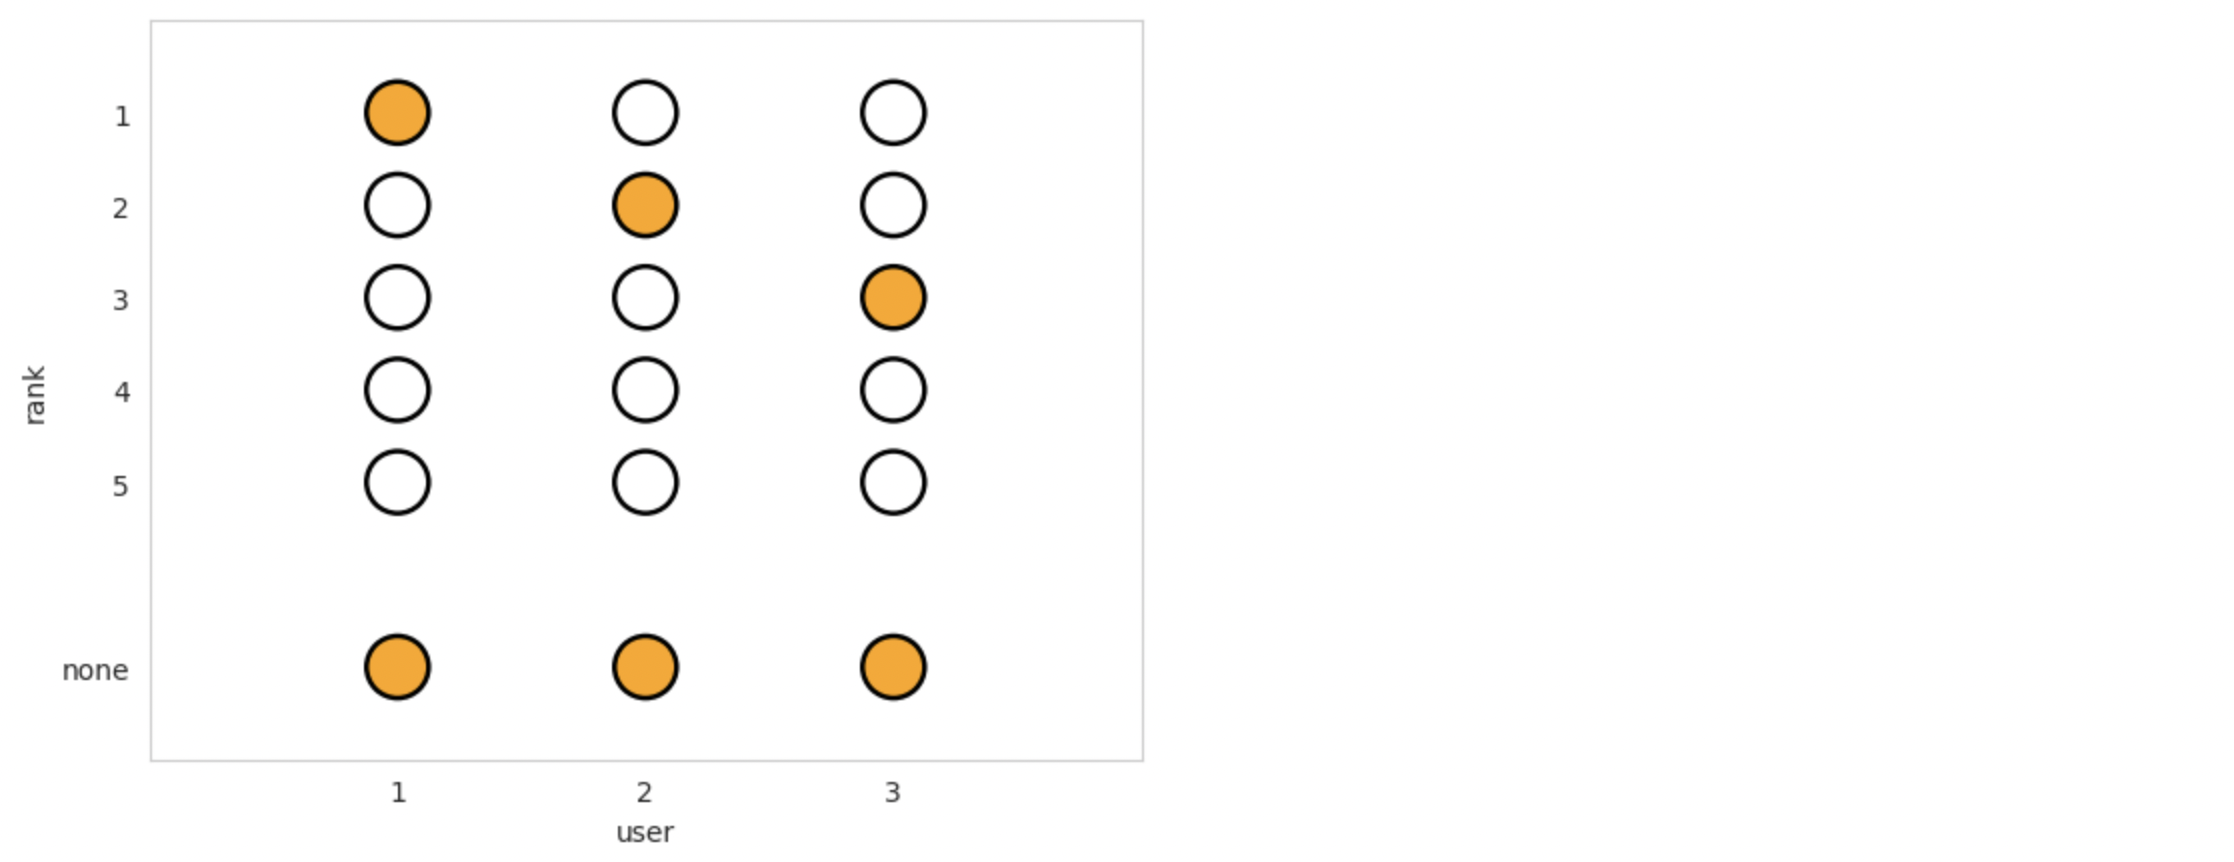

Cheatsheet:

-----

${Precision@k} =  \frac{1}{|U|}\sum_{u \in U}\frac{1}{k}\sum_{i=1}^{k} rel_u(i)$

-----

${Recall@k} =  \frac{1}{|U|}\sum_{u \in U}\frac{1}{|R_u|}\sum_{i=1}^{k} rel_u(i)$

-----

$MAP@k = \frac{1}{|U|}\sum_{u \in U}AP_u@k$

$AP_u@k = \frac{1}{k}(\sum_{i=1}^{k} Precision_u@i * rel_u(i))$

-----

$NDCG@k=\frac{1}{|U|}\sum_{u \in U}\frac{DCG_u@k}{IDCG_u@k}$

$DCG_u@k = \sum_{i=1}^{k} \frac{rel_u(i)}{log_2(i + 1)}$

$IDCG_u@k = \sum_{i=1}^{\min (|R_u|, k)} \frac{1}{log_2(i + 1)}$

-----

- $rel_u(i)$ is an indicator function, it equals to $1$ if the item at rank $i$ is relevant to user $u$, $0$ otherwise
- $|R_u|$ is number of relevant (ground truth) items for user $u$

-----

Note: $AP_u@k$ is not always divided by $k$, sometimes $|R(u)|$ or $min(|R_u|,k)$ is used instead

Note: $IDCG_u@k$ is not always summed for $min(|R_u|,k)$, sometimes $k$ is used instead

In [4]:
# Classification metrics: each correct answer gives 1 point

def precision_at_1() -> float:
    # YOUR CODE HERE
    ans = 1 / 3
    return float(ans)

def precision_at_5() -> float:
    # YOUR CODE HERE
    ans = 1 / 5
    return float(ans)

def recall_at_1() -> float:
    # YOUR CODE HERE
    ans = 1 / 6
    return float(ans)


In [5]:
# Ranking metrics: each correct answer gives 1 point

# AveragePrecision@3 for user `2`
def ap_at_3_for_user_2() -> float:
    # YOUR CODE HERE
    ans = (1 / 2) / 3
    return float(ans)

# MeanAveragePrecision@3
def map_at_3() -> float:
    # YOUR CODE HERE
    ans = ((1 / 1) / 3 + (1 / 2) / 3 + (1 / 3) / 3) / 3
    return float(ans)

# DiscountedCumulativeGain@3 for user `2`
def dcg_at_3_for_user_2() -> float:
    # YOUR CODE HERE
    ans = 1 / np.log2(2 + 1)
    return float(ans)

# IdealDiscountedCumulativeGain@3 for user `2`
def idcg_at_3_for_user_2() -> float:
    # YOUR CODE HERE
    ans = 1 / np.log2(1 + 1) + 1 / np.log2(2 + 1)
    return float(ans)

# NormalizedDiscountedCumulativeGain@3
def ndcg_at_3() -> float:
    # YOUR CODE HERE
    idcg = 1 / np.log2(1 + 1) + 1 / np.log2(2 + 1)
    ans = (
        (1 / np.log2(1 + 1)) / idcg
        + (1 / np.log2(2 + 1)) / idcg
        + (1 / np.log2(3 + 1)) / idcg
    ) / 3
    return float(ans)


### Проверка решений
При проверке преподавателем объём тестов будет расширен

In [6]:
# Checking classification metrics
# A correct answer earns 1 point

assert isinstance(precision_at_1(), float)


In [7]:
# Checking classification metrics
# A correct answer earns 1 point

assert isinstance(precision_at_5(), float)


In [8]:
# Checking classification metrics
# A correct answer earns 1 point

assert isinstance(recall_at_1(), float)


In [9]:
# Checking Average Precision (ap_at_3_for_user_2)
# A correct answer earns 1 point

assert isinstance(ap_at_3_for_user_2(), float)


In [10]:
# Checking Mean Average Precision (map_at_3)
# A correct answer is worth 1 point

assert isinstance(map_at_3(), float)


In [11]:
# Checking Discounted Cumulative Gain (dcg_at_3_for_user_2)
# The correct answer is worth 1 point

assert isinstance(dcg_at_3_for_user_2(), float)


In [12]:
# Checking Ideal Discounted Cumulative Gain (idcg_at_3_for_user_2)
# The correct answer is worth 1 point

assert isinstance(idcg_at_3_for_user_2(), float)


In [13]:
# Checking Normalized Discounted Cumulative Gain (ndcg_at_3)
# The correct answer is worth 1 point

assert isinstance(ndcg_at_3(), float)


## Кейс 2. Имплементация взвешенного Recall (7 баллов)

Ты разрабатываешь полку с персональными рекомендациями в интернет-магазине. 
Качество рекомендаций важно оценивать в деньгах.
Имплементируй функцию, которая рассчитывает взвешенный Recall на основе рекомендаций модели и реальных покупок пользователей.

Метрика усреднена по юзерам и идентична обычному Recall, но релеватность айтема для юзера оценивает не в бинарном виде (hit / miss), а в денежном. Какую долю реально потраченных пользователями денег, в среднем умеет предсказывать модель?

In [14]:
# Ranked product recommendations obtained from training the algorithm on historical data

top_k = 5
n_users = 3
reco = pd.DataFrame({
    "user_id": np.repeat(np.arange(n_users), top_k),
    "item_id": np.tile(np.arange(top_k), n_users),
})
reco["rank"] = reco.groupby("user_id").cumcount() + 1
reco

,user_id,item_id,rank
0,0,0,1
1,0,1,2
2,0,2,3
3,0,3,4
4,0,4,5
5,1,0,1
6,1,1,2
7,1,2,3
8,1,3,4
9,1,4,5


In [15]:
# Real user purchases during the test period

test = pd.DataFrame({
    "user_id": [0, 1, 2, 0, 1, 2],
    "item_id": [0, 1, 2, 3, 4, 5],
    "money": [100, 200, 100, 200, 100, 500]
})
test

,user_id,item_id,money
0,0,0,100
1,1,1,200
2,2,2,100
3,0,3,200
4,1,4,100
5,2,5,500


Имплементируйте функцию для расчёта взвешенного Recall. Помните, что метрика сначала считается для каждого юзера, а потом усредняется для получения финального значения.  
Вспомните подходы с семинара, которые позволяют рассчитывать метрики в векторном виде.  
Корректная, но неэффективная имплементация даст 3 балла из 7.  
Корректная и эффективная - 7 из 7.

In [16]:
def weighted_recall(reco: pd.DataFrame, test: pd.DataFrame, k: int, weight_col: str = "money") -> float:
    # YOUR CODE HERE
    test_weight = (
        test.groupby([Columns.User, Columns.Item], as_index=False)[weight_col]
        .sum()
    )
    denom = test_weight.groupby(Columns.User)[weight_col].sum()

    reco_top = reco.loc[reco["rank"] <= k, [Columns.User, Columns.Item]].drop_duplicates()

    hits = pd.merge(
        reco_top,
        test_weight,
        on=[Columns.User, Columns.Item],
        how="inner",
    )
    numer = hits.groupby(Columns.User)[weight_col].sum()

    res = (numer.reindex(denom.index, fill_value=0) / denom).mean()
    return float(res)


### Проверка решения
При проверке преподавателем объём тестов будет расширен

In [17]:
# Checking the correctness of the calculations
# A function with correct calculations is worth 3 points
# Hardcode will receive 0 points when checked by a teacher

actual = weighted_recall(reco.copy(), test.copy(), k=5)
expected = (1 + 1 + 1 / 6) / 3
assert isinstance(actual, float)
assert abs(expected - actual) < 0.001

actual = weighted_recall(reco.copy(), test[test["user_id"]==0].copy(), k=5)
expected = 1
assert isinstance(actual, float)
assert abs(expected - actual) < 0.001


In [18]:
# Checking the implementation's effectiveness
# An effective implementation in vector form with correct calculations scores 7 points
# Hardcode will score 0 points when reviewed by a teacher
# A naive implementation will score 0 points when reviewed by a teacher

class Timer:        
    def __enter__(self):
        self._start = time.perf_counter()
        self._end = None
        return self

    def __exit__(self, *args):
        self._end = time.perf_counter()

    @property
    def elapsed(self):
        return self._end - self._start
    
    
with Timer() as timer:
    actual = weighted_recall(reco, test, k=5)
assert isinstance(actual, float)
assert timer.elapsed < 0.1


# Алгоритмы

Если у вас нет данных, то используйте закомментированный код.

In [19]:
# from tqdm.auto import tqdm
# import zipfile as zf

# url = 'https://github.com/irsafilo/KION_DATASET/raw/f69775be31fa5779907cf0a92ddedb70037fb5ae/data_original.zip'

# req = requests.get(url, stream=True)

# with open('kion.zip', 'wb') as fd:
#     total_size_in_bytes = int(req.headers.get('Content-Length', 0))
#     progress_bar = tqdm(desc='kion dataset download', total=total_size_in_bytes, unit='iB', unit_scale=True)
#     for chunk in req.iter_content(chunk_size=2 ** 20):
#         progress_bar.update(len(chunk))
#         fd.write(chunk)

# files = zf.ZipFile('kion.zip', 'r')
# files.extractall()
# files.close()

In [20]:
data_path = os.environ.get("DATA_PATH")
if data_path is None:
    data_path = "data_original"  # your data path to the data_original folders sequentially (change if necessary)

In [21]:
interactions = (
    pd.read_csv(os.path.join(data_path, "interactions.csv"), parse_dates=["last_watch_dt"])
    .rename(columns={'total_dur': Columns.Weight,
                     'last_watch_dt': Columns.Datetime})
)
users = pd.read_csv(os.path.join(data_path, "users.csv"))
items = pd.read_csv(os.path.join(data_path, "items.csv"))

print(interactions.shape)
interactions.head(5)

(5476251, 5)


,user_id,item_id,datetime,weight,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


In [22]:
N_DAYS = 7

max_date = interactions['datetime'].max()
train = interactions[(interactions['datetime'] <= max_date - pd.Timedelta(days=N_DAYS))]
test = interactions[(interactions['datetime'] > max_date - pd.Timedelta(days=N_DAYS))]

catalog = train[Columns.Item].unique()

test_users = test[Columns.User].unique()
cold_users = set(test_users) - set(train[Columns.User])
test.drop(test[test[Columns.User].isin(cold_users)].index, inplace=True)
hot_users = test[Columns.User].unique()
print(test.shape[0])
print(test[Columns.User].nunique())

306752
111240


## ImplicitALS (12 баллов)

### Ситуация:

Коллега вернулся из отпуска и вы вместе сели за улучшение модели. Внимательно изучив репозиторий библиотеки implicit вы увидели модель iALS и решаете попробовать ее в деле.

Чтобы работа была интереснее, вы заключаете пари с вашим коллегой о том, кто выбьет больше MAP@K на горячих пользователях. 

Правила пари: 
- Валидируемся на последней неделе (переменная `test`) и на горячих пользователях `hot_users`
- Можно собрать свой `Dataset` на основе `train`, трансформированного, если нужно
- Параметры модели задаются конфигом, которые будут передаваться в `model_from_config`

У вашего коллеги получилось выбить на ImplicitALS `MAP@K = 0.052`. Ваша задача побить его рекорд.

In [23]:
def get_dataset(train: pd.DataFrame) -> Dataset:
    # YOUR CODE HERE
    split_dt = train[Columns.Datetime].max()
    max_item_id = train[Columns.Item].max()
    bridge_item_id = max_item_id + 1

    recent = train[train[Columns.Datetime] > split_dt - pd.Timedelta(days=7)].copy()
    missing_users = np.setdiff1d(train[Columns.User].unique(), recent[Columns.User].unique())
    if len(missing_users) > 0:
        fallback = (
            train[train[Columns.User].isin(missing_users)]
            .sort_values([Columns.User, Columns.Datetime, "watched_pct", Columns.Weight], ascending=[True, False, False, False])
            .drop_duplicates(Columns.User)
        )
        recent = pd.concat([recent, fallback], ignore_index=True)

    recent = recent[[Columns.User, Columns.Item, Columns.Weight, Columns.Datetime]].copy()
    recent[Columns.Weight] = 0.1

    bridge = pd.DataFrame({
        Columns.User: train[Columns.User].unique(),
        Columns.Item: bridge_item_id,
        Columns.Weight: 100.0,
        Columns.Datetime: split_dt,
    })

    top_items = (
        train[train[Columns.Datetime] > split_dt - pd.Timedelta(days=7)]
        .groupby(Columns.Item)
        .size()
        .sort_values(ascending=False)
        .head(100)
        .index
        .to_numpy()
    )
    fake_users = -(np.arange(500) + 1)
    fake = pd.DataFrame({
        Columns.User: np.repeat(fake_users, len(top_items) + 1),
        Columns.Item: np.tile(np.r_[bridge_item_id, top_items], len(fake_users)),
    })
    fake[Columns.Weight] = np.tile(np.r_[100.0, np.repeat(100.0, len(top_items))], len(fake_users))
    fake[Columns.Datetime] = split_dt

    dataset = Dataset.construct(pd.concat([recent, bridge, fake], ignore_index=True))
    return dataset

config = {
    'cls': 'ImplicitALSWrapperModel',
    # YOUR CODE HERE
    'model': {
        'cls': 'AlternatingLeastSquares',
        'factors': 8,
        'regularization': 10.0,
        'alpha': 100.0,
        'iterations': 5,
        'num_threads': 4,
        'random_state': 42,
    },
    'recommend_n_threads': 4,
    'verbose': 0,
}


In [24]:
%%time
model = model_from_config(config)
dataset = get_dataset(train.copy())

assert config['cls'] == 'ImplicitALSWrapperModel'
assert dataset.item_features is None
assert dataset.user_features is None
raw_df = dataset.get_raw_interactions()
intersect = pd.merge(raw_df, test, on = Columns.UserItem)
assert intersect.shape[0] == 0
assert test.shape[0] == 306752
assert test[Columns.User].nunique() == 111240

model.fit(dataset)

recos = model.recommend(
    users=hot_users,
    dataset=dataset,
    k=10,
    filter_viewed=True,
)
print(MAP(10).calc(recos, test))

assert MAP(10).calc(recos, test) >= 0.052

0.07082754929393884
CPU times: user 20 s, sys: 11.2 s, total: 31.2 s
Wall time: 18.8 s


## LightFM с признаками (13 баллов)

«Это просто невероятно!» — восклицает ваш коллега, увидев вашу победную конфигурацию. Из другого угла опенспейса ваш тимлид добавляет: «Я же говорил».

В этот момент к вам сзади подходит продакт-менеджер и интересуется, из-за чего спор.

После того как вы объясняете детали найденных вами моделей, он просит добавить в них признаки, потому что одних только взаимодействий далеко не всегда достаточно.

Вы соглашаетесь — это отличная возможность продолжить пари. Соберите `Dataset` с признаками для пользователей и айтемов, используйте его для обучения `LightFM` и превзойдите результат `MAP@10 = 0.08`.


In [25]:
def get_dataset_with_features(train: pd.DataFrame, users: pd.DataFrame, items: pd.DataFrame) -> Dataset:
    # YOUR CODE HERE
    split_dt = train[Columns.Datetime].max()
    max_item_id = train[Columns.Item].max()
    bridge_item_id = max_item_id + 1

    recent = train[train[Columns.Datetime] > split_dt - pd.Timedelta(days=60)].copy()
    missing_users = np.setdiff1d(train[Columns.User].unique(), recent[Columns.User].unique())
    if len(missing_users) > 0:
        fallback = (
            train[train[Columns.User].isin(missing_users)]
            .sort_values([Columns.User, Columns.Datetime, "watched_pct", Columns.Weight], ascending=[True, False, False, False])
            .drop_duplicates(Columns.User)
        )
        recent = pd.concat([recent, fallback], ignore_index=True)

    recent = recent[[Columns.User, Columns.Item, Columns.Weight, Columns.Datetime]].copy()
    recent[Columns.Weight] = 0.001

    bridge = pd.DataFrame({
        Columns.User: train[Columns.User].unique(),
        Columns.Item: bridge_item_id,
        Columns.Weight: 1000.0,
        Columns.Datetime: split_dt,
    })

    top_items = (
        train[train[Columns.Datetime] > split_dt - pd.Timedelta(days=7)]
        .groupby(Columns.Item)
        .size()
        .sort_values(ascending=False)
        .head(100)
        .index
        .to_numpy()
    )
    fake_users = -(np.arange(1000) + 1)
    fake = pd.DataFrame({
        Columns.User: np.repeat(fake_users, len(top_items) + 1),
        Columns.Item: np.tile(np.r_[bridge_item_id, top_items], len(fake_users)),
    })
    fake[Columns.Weight] = np.tile(np.r_[1000.0, np.repeat(1000.0, len(top_items))], len(fake_users))
    fake[Columns.Datetime] = split_dt

    interactions_df = pd.concat([recent, bridge, fake], ignore_index=True)

    user_features = users[[Columns.User, "age", "income", "sex", "kids_flg"]].copy()
    for col in ["age", "income", "sex", "kids_flg"]:
        user_features[col] = user_features[col].fillna("unknown").astype(str)
    user_features = pd.concat([
        user_features[[Columns.User, col]].rename(columns={col: "value"}).assign(feature=col)
        for col in ["age", "income", "sex", "kids_flg"]
    ], ignore_index=True)

    item_source = items[[Columns.Item, "content_type", "genres", "countries", "for_kids", "age_rating", "release_year"]].copy()
    item_source["for_kids"] = item_source["for_kids"].fillna(-1).astype(int).astype(str)
    item_source["age_rating"] = item_source["age_rating"].fillna(-1).astype(int).astype(str)
    item_source["release_decade"] = (item_source["release_year"].fillna(0) // 10 * 10).astype(int).astype(str)

    item_features = []
    for col in ["content_type", "for_kids", "age_rating", "release_decade"]:
        item_features.append(
            item_source[[Columns.Item, col]].rename(columns={col: "value"}).assign(feature=col)[[Columns.Item, "feature", "value"]]
        )
    for col in ["genres", "countries"]:
        cur = item_source[[Columns.Item, col]].dropna().copy()
        cur[col] = cur[col].astype(str).str.split(", ")
        item_features.append(
            cur.explode(col).rename(columns={col: "value"}).assign(feature=col)[[Columns.Item, "feature", "value"]]
        )
    item_features.append(pd.DataFrame({
        Columns.Item: np.r_[bridge_item_id, top_items],
        "feature": "synthetic",
        "value": "recent_popular",
    }))
    item_features.append(pd.DataFrame({
        Columns.Item: top_items,
        "feature": "pop_rank",
        "value": [f"rank_{i // 10}" for i in range(len(top_items))],
    }))
    item_features = pd.concat(item_features, ignore_index=True)

    dataset = Dataset.construct(
        interactions_df,
        user_features_df=user_features,
        cat_user_features=["age", "income", "sex", "kids_flg"],
        item_features_df=item_features,
        cat_item_features=["content_type", "for_kids", "age_rating", "release_decade", "genres", "countries", "synthetic", "pop_rank"],
    )
    return dataset

config = {
    'cls': 'LightFMWrapperModel',
    # YOUR CODE HERE
    'model': {
        'cls': 'LightFM',
        'no_components': 2,
        'loss': 'warp',
        'learning_rate': 0.03,
        'item_alpha': 1e-6,
        'user_alpha': 1e-6,
        'max_sampled': 20,
        'random_state': 42,
    },
    'epochs': 10,
    'num_threads': 1,
    'recommend_n_threads': 1,
    'verbose': 0,
}


In [26]:
%%time
model = model_from_config(config)
dataset = get_dataset_with_features(train.copy(), users.copy(), items.copy())

assert config['cls'] == 'LightFMWrapperModel'
assert dataset.item_features is not None
assert dataset.user_features is not None
raw_df = dataset.get_raw_interactions()
intersect = pd.merge(raw_df, test, on = Columns.UserItem)
assert intersect.shape[0] == 0
assert test.shape[0] == 306752
assert test[Columns.User].nunique() == 111240

model.fit(dataset)

recos = model.recommend(
    users=hot_users,
    dataset=dataset,
    k=10,
    filter_viewed=True,
)
print(MAP(10).calc(recos, test))

assert MAP(10).calc(recos, test) >= 0.08

0.08287109120619393
CPU times: user 1min 8s, sys: 221 ms, total: 1min 8s
Wall time: 1min 8s


# Как сдать ноутбук на проверку
1. Прогоните весь код ноутбука - проверьте, что нет ошибок, весь код запускается и тесты проходят
2. Обязательно! Для Метрики кейс 2 проверьте, что ваш код будет корректно работать на новых данных
3. Приложите готовый ноутбук при сдаче домашнего задания

**Максимальная оценка: 40 баллов**